# XOPT - INTERPRETABLE METAHEURISTICS FOR COMBINATORIAL OPTIMIZATION

## HIERARCHICAL CLUSTERING

Graph analysis and extraction of the connected component of the best solution. The bipartite graph is composed of two independent vertex sets:

    1. First set represents the facility (resource) nodes;
    2. Second set represents the solution nodes.

### SETTING THE ENVIRONMENT

Importing the libraries:

In [1]:
import sys

from pathlib import Path

parent_path = Path().resolve().parent.parent

if str(parent_path) not in sys.path:
    sys.path.insert(0, str(parent_path))

In [2]:
import agnes
import random
import pymedian

import matplotlib.pyplot as plt

This cell locates the "instances" folder in the project root and counts how many p-median instance files exist:

In [3]:
ROOT          = Path.cwd().resolve().parent.parent
INSTANCES_DIR = ROOT / "instances"

if not INSTANCES_DIR.exists():
    raise FileNotFoundError(f"Instances folder not found: {INSTANCES_DIR}")

print(f"Total number of p-median instances: {len(list(INSTANCES_DIR.glob('pmed[0-9]*.txt')))}")

Total number of p-median instances: 40


### APPLYING

We selected a few classic p-median instances and recorded the results obtained:

In [4]:
instance      = "pmed11.txt"
instance_path = str(INSTANCES_DIR / instance)

summary, details = pymedian.solve_pmedian(instance_path,
                                          restarts=8   ,
                                          max_iter=25  ,
                                          factor  =2   ,
                                          details_format='indices')


print(f"Instance {summary['instance'][:-4]} ({summary['p']}-{summary['n']})")

print()
print(f"  K-Medoids ({summary['kmedoids_cost']}): {summary['medoids'          ][:10]}")
print(f"  TSPMED    ({summary['tspmed_cost'  ]}): {summary['tspmed_facilities'][:10]}")

print()
print(f"Obs.: Distinct solutions recorded in long term memory is {summary['long_term_mem']}!")

Instance /home/rei-luisinho/xopt/instances/pmed11 (5-300)

  K-Medoids (7696.0): [98, 201, 167, 24, 31]
  TSPMED    (7696.0): [98, 201, 167, 24, 31]

Obs.: Distinct solutions recorded in long term memory is 806!


### OBTAINING THE CONNECTED COMPONENT SUBGRAPH

A disjoint-set (Union–Find) data structure is employed to process adjacency lists by **merging elements that share connectivity.**

- The partitioned elements correspond to vertices in the second independent set of the bipartite graph.
- Each resulting partition defines a connected component of the graph.

**Algorithm description:**

1. All solutions are initially considered as singleton disjoint sets.
2. For each facility adjacency list that contains multiple solutions, the associations are examined.
3. Solutions that co-occur in the same facility adjacency list are unified into a single disjoint set.

Reading the bipartite graph:

In [5]:
solutions = details["long_term_memory"]

n_facilities = summary["n"]
n_solutions  = len(solutions)


bigraph = agnes.BiGraph()

bigraph.N = n_facilities
bigraph.L = n_solutions

facility_to_solutions = [
    []
    for _ in range(n_facilities)
]

for solution_idx, solution in enumerate(solutions):
    for facility_idx in solution["facilities"]:
        facility_to_solutions[facility_idx].append(solution_idx)

bigraph.adj_list = facility_to_solutions


print(f"Characteristics of the bipartite graph: {str(bigraph)}")

Characteristics of the bipartite graph: N_300_L_806


Merging associated solutions in the bipartite graph:

In [6]:
unionfind = agnes.UnionFind(bigraph.L)

for adj in bigraph:
    if len(adj) < 2:
        continue

    u = adj[0]
    for v in adj[1:]:
        unionfind.union(u, v)

In [7]:
random_idx = random.randint(0, bigraph.N - 1)
adjacency  = bigraph.adj_list[random_idx]

print(f"Random adjacency list at facility index {random_idx}.")
print()

first_root      = None
in_same_cluster = True

for vertex in adjacency:
    root = unionfind.find(vertex)

    if first_root is None:
        first_root = root
    elif root != first_root:
        in_same_cluster = False

print(f"All vertices in same cluster: {in_same_cluster}")

Random adjacency list at facility index 79.

All vertices in same cluster: True


Extracting connected components and counting facilities:

In [8]:
components        = {}
unused_facilities = []

for facility, adjacency in enumerate(bigraph):
    if adjacency:
        root = unionfind.find(adjacency[0])

        if root not in components:
            components[root] = []

        components[root].append(facility)
    else:
        unused_facilities.append(facility)


print(f"Total connected components is             {len(components       )}.")
print(f"Facilities without incident solutions are {len(unused_facilities)}!")

Total connected components is             1.
Facilities without incident solutions are 241!


The analysis revealed that the bipartite graph (restricted to facilities with at least one incident solution) contains a single connected component. This result implies that all vertices in the considered partition are indirectly connected through shared facilities. In other words, there exists a path between any pair of vertices in the graph. Consequently:

- The structure is fully connected at the component level.
- **No natural fragmentation or isolated substructures are present.**
- Any clustering performed afterward will reflect internal structural variations rather than separations caused by disconnected subgraphs.

From a graph-theoretic perspective, the absence of multiple connected components indicates that the facility partition induces a globally cohesive structure.

### HIERARCHICAL CLUSTERING

Finding the index of the best solution and its facilities:

In [9]:
solutions = details["long_term_memory"]

best_idx, best_solution = min(
    enumerate(solutions),
    key=lambda x: x[1]["cost"]
)

best_cost = best_solution["cost"      ]
best_sol  = best_solution["facilities"]


print(f"Best solution found at index {best_idx} with cost {best_cost}.")

Best solution found at index 467 with cost 7696.0.


Hierarchical clustering is performed using a threshold of 1.0, resulting in clusters whose set-intersection similarity corresponds to at least one shared solution between facilities:

In [10]:
THRESHOLD = 1.0


dendrogram_data = agnes.agnes(
    bigraph, thresh=THRESHOLD
)

print(f"Number of dendrograms (threshold {THRESHOLD}): {len(dendrogram_data)}")

Number of dendrograms (threshold 1.0): 10


Showing the linkage with a facility from the best solution:

In [11]:
facilities_by_linkage = {}

for facility in map(int, best_sol):
    linkage_id = agnes.vertex2linkage(
        facility, dendrogram_data
    )

    facilities_by_linkage.setdefault(linkage_id, []).append(facility)


print("Facilities grouped by linkage:")
print()

for linkage_id, facilities in facilities_by_linkage.items():
    print(f"Linkage {linkage_id}: {facilities}")

print()
print(f"Number of facilities in best solution : {len(best_sol)}")
print(f"Number of distinct linkages required  : {len(facilities_by_linkage)}")

Facilities grouped by linkage:

Linkage 6: [23, 97]
Linkage 7: [30, 166, 200]

Number of facilities in best solution : 5
Number of distinct linkages required  : 2


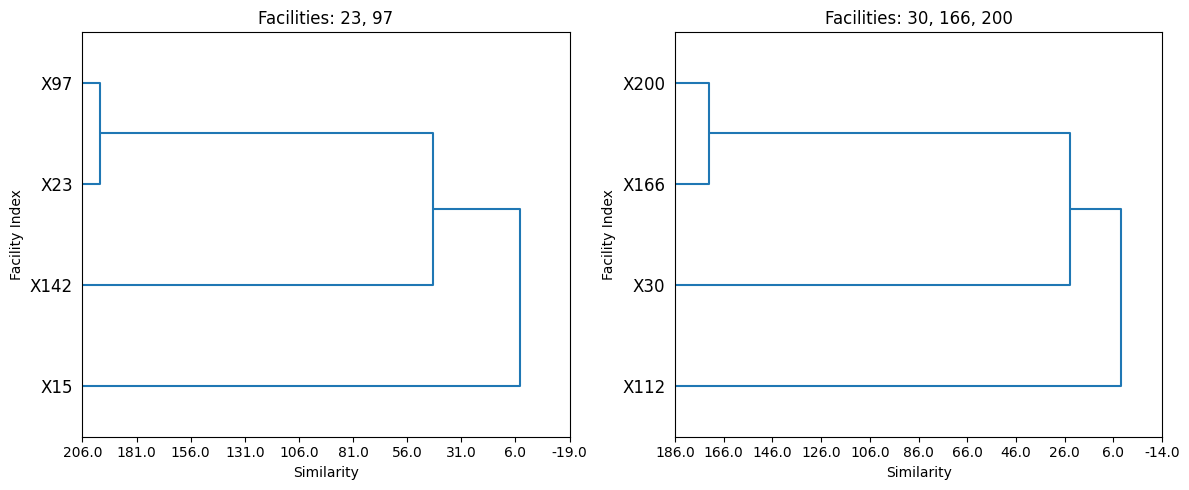

In [12]:
unique_linkages = list(facilities_by_linkage.keys())

fig, axes = plt.subplots(
    1, len(unique_linkages), figsize=(6 * len(unique_linkages), 5)
)

if len(unique_linkages) == 1:
    axes = [axes]

for ax, linkage_id in zip(axes, unique_linkages):
    facilities = facilities_by_linkage[linkage_id]

    agnes.dendrogram(
        dendrogram_data[linkage_id],
        bigraph.N,
        bigraph.L,
        ax=ax
    )

    ax.set_title (
        f"Facilities: {', '.join(map(str, facilities))}"
    )
    ax.set_xlabel("Similarity"    )
    ax.set_ylabel("Facility Index")

plt.tight_layout()
plt.show()